# Supervised Learning: Drivers of Economic Complexity

**Moody's Ratings Capstone — Natural Resource Dependency Classification**  
**NB5 of 5 · Pipeline Step: Modelling**

This notebook runs regularised regression (LASSO, Ridge, Elastic Net) and Random Forest to predict log(ECI) from macro and natural resource features. It reads from `intermediary/Master.csv` and `intermediary/clustersagg.csv`, outputs to `Graphics/NB5/`, and is compatible with the NB2–NB4 pipeline conventions.

## 0. Setup and Data Loading

Imports, output directories, and data loading from pipeline intermediary files. The 54-country sample is the same as NB4's `include_list`. Cluster assignments from NB4 (`clustersagg.csv`) are merged for optional stratified reporting — they are not used as model features here to avoid circular reasoning (clusters are derived from NR production, which is already a predictor).

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import warnings
warnings.filterwarnings('ignore')

# ── Output directories ────────────────────────────────────────────────────────
OUT = os.path.join('Graphics', 'NB5')
os.makedirs(OUT, exist_ok=True)

# ── 0.1 Load master panel ─────────────────────────────────────────────────────
master = pd.read_csv('intermediary/Master.csv')
print(f"Master: {len(master)} obs, {master['Country Code'].nunique()} countries")

# ── 0.2 54-country sample (same as NB4) ──────────────────────────────────────
include_list = [
    'AGO', 'ARE', 'AZE', 'BFA', 'BHR', 'BOL', 'CHL', 'CIV', 'CMR',
    'COD', 'COG', 'DZA', 'ECU', 'EGY', 'ETH', 'GAB', 'GHA', 'GIN',
    'GNQ', 'IDN', 'IRN', 'IRQ', 'KAZ', 'KEN', 'KWT', 'LAO', 'LBR',
    'LBY', 'MDG', 'MLI', 'MMR', 'MNG', 'MOZ', 'MWI', 'MYS', 'NER',
    'NGA', 'OMN', 'PNG', 'QAT', 'RUS', 'RWA', 'SAU', 'TCD', 'TGO',
    'TTO', 'TZA', 'UGA', 'UZB', 'VEN', 'VNM', 'YEM', 'ZMB', 'ZWE',
]

# ── 0.3 Filter to sample and year range ──────────────────────────────────────
filter_sample = True

df = master[(master['Year'] >= 1995) & (master['Year'] <= 2019)].dropna(subset=['Economic Complexity Index']).copy()
df = df.sort_values(['Country Code', 'Year'])

if filter_sample:
    df = df[df['Country Code'].isin(include_list)]

df['Resource_Rich'] = df['Country Code'].isin(include_list).astype(int)
print(f"After sample filter: {df['Country Code'].nunique()} countries")

# ── 0.4 Merge cluster assignments from NB4 ───────────────────────────────────
clusters = pd.read_csv('intermediary/clustersagg.csv')
# Keep one row per country (clustersagg has one row per country, not panel)
cluster_map = clusters[['Country Code', 'ClusterLabels']].drop_duplicates('Country Code')
df = df.merge(cluster_map, on='Country Code', how='left')
print(f"Cluster coverage: {df['ClusterLabels'].notna().sum()} / {len(df)} rows")

Master: 3275 obs, 131 countries
After sample filter: 54 countries
Cluster coverage: 1350 / 1350 rows


## 1. Feature Engineering

Lagged ECI (one-year within-country lag) is included as a predictor to capture persistence. Two interaction terms are added to test whether natural resource production amplifies or diminishes the returns to human capital and institutional quality. Log transforms are applied to right-skewed variables to reduce the influence of extreme values.

In [2]:
# ── ECI lag ───────────────────────────────────────────────────────────────────
df['L1_ECI'] = df.groupby('Country Code')['Economic Complexity Index'].shift(1)
df = df.dropna()

# ── Interactions ──────────────────────────────────────────────────────────────
df['HCI_x_ProductionValue']       = df['Human capital index'] * df['Total_Production_Value']
df['RuleOfLaw_x_ProductionValue'] = df['Rule of law index']   * df['Total_Production_Value']

# ── Feature lists ─────────────────────────────────────────────────────────────
base_features = [
    'Total_Production_Value',
    'Human capital index',
    'Rule of law index',
    'Political stability — estimate',
    'Trade (% of GDP)',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Share of investment in GDP',
    'Domestic credit to private sector (% of GDP)',
    'Landlocked',
    'Urban population (% of total population)',
    'Government revenue',
    'Capital depreciation rate',
    'Use of IMF credit (DOD, current US$)',
    'Real interest rate (%)',
    'Inflation, consumer prices (annual %)',
    'Access to electricity (% of population)',
    'Adjusted savings: gross savings (% of GNI)',
    'L1_ECI'
]
all_features = base_features + ['HCI_x_ProductionValue', 'RuleOfLaw_x_ProductionValue']

print(f"Total features: {len(all_features)} (18 base + 1 group + 2 interactions)")

# ── Log transforms ────────────────────────────────────────────────────────────
min_val = df['Economic Complexity Index'].min()
df['ECI_shifted'] = df['Economic Complexity Index'] - min_val + 1
df['Economic Complexity Index'] = np.log(df['ECI_shifted'])

min_val = df['L1_ECI'].min()
df['L1_ECI_shifted'] = df['L1_ECI'] - min_val + 1
df['L1_ECI'] = np.log(df['L1_ECI_shifted'])

log_features = [
    'Human capital index',
    'Total_Production_Value',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Government revenue',
    'Use of IMF credit (DOD, current US$)',
]
df[log_features] = np.log1p(df[log_features])
df[log_features] = df[log_features].replace([np.inf, -np.inf], np.nan)
df = df.dropna()
print(f"After transforms: {len(df)} obs")

Total features: 20 (18 base + 1 group + 2 interactions)
After transforms: 1240 obs


## 2. Model Training

All four models are fitted on the full dataset; cross-validation is used only for hyperparameter selection (alpha / l1_ratio), not held-out evaluation. TimeSeriesSplit respects the temporal structure of the panel. In-sample fit metrics are reported alongside CV-selected hyperparameters.

In [3]:
# ── Arrays ────────────────────────────────────────────────────────────────────
y = df['Economic Complexity Index'].values
X = df[all_features].copy()

print(f"Observations: {X.shape[0]} | Features: {X.shape[1]}")

# ── Scale on full data ────────────────────────────────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X.values)
y_train = y

# ── CV splitter ───────────────────────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5, gap=1)

# ── Fit models ────────────────────────────────────────────────────────────────
l1_ratios = [0.5]

lasso   = LassoCV(cv=tscv, random_state=42, max_iter=10000).fit(X_train, y_train)
ridge   = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=tscv).fit(X_train, y_train)
elastic = ElasticNetCV(l1_ratio=l1_ratios, cv=tscv, random_state=42, max_iter=10000).fit(X_train, y_train)
rf      = RandomForestRegressor(
    n_estimators=200, max_depth=4, min_samples_leaf=10,
    random_state=42, n_jobs=-1, oob_score=True
).fit(X_train, y_train)

models = {'LASSO': lasso, 'Ridge': ridge, 'Elastic Net': elastic, 'Random Forest': rf}
print("\n✓ All models fitted on full dataset")
print(f"  Elastic Net  →  best l1_ratio: {elastic.l1_ratio_:.2f}  |  alpha: {elastic.alpha_:.4f}")
print(f"  LASSO        →  best alpha:    {lasso.alpha_:.4f}")
print(f"  Ridge        →  best alpha:    {ridge.alpha_:.4f}")
print(f"  RF OOB R²    →  {rf.oob_score_:.4f}")

Observations: 1240 | Features: 20

✓ All models fitted on full dataset
  Elastic Net  →  best l1_ratio: 0.50  |  alpha: 0.0124
  LASSO        →  best alpha:    0.0066
  Ridge        →  best alpha:    0.8111
  RF OOB R²    →  0.7303


## 3. Diagnostics

VIF is computed on the full scaled feature matrix to flag multicollinearity. In-sample performance metrics (R², RMSE, MAE) are reported for all four models. The summary coefficient table combines signed coefficients, normalised importances, VIF, and selection indicators in one view.

In [4]:
# ── In-sample fit metrics ─────────────────────────────────────────────────────
perf_rows = []
for name, model in models.items():
    pred = model.predict(X_train)
    perf_rows.append({
        'Model': name,
        'R²':   round(model.score(X_train, y_train), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_train, pred)), 4),
        'MAE':  round(mean_absolute_error(y_train, pred), 4),
    })

perf_df = pd.DataFrame(perf_rows).sort_values('R²', ascending=False).reset_index(drop=True)
print(perf_df.to_string(index=False))

# ── VIF ───────────────────────────────────────────────────────────────────────
vif_data = pd.DataFrame({
    'Feature': all_features,
    'VIF':     [variance_inflation_factor(X_train, i) for i in range(X_train.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)
high_vif = vif_data[vif_data['VIF'] > 10]

print(f"\nHigh-VIF features (>10):")
print(high_vif.to_string(index=False) if len(high_vif) else "  None")

        Model     R²   RMSE    MAE
Random Forest 0.7846 0.1044 0.0651
        Ridge 0.7437 0.1139 0.0747
  Elastic Net 0.7313 0.1166 0.0741
        LASSO 0.7295 0.1170 0.0741

High-VIF features (>10):
  None


## 4. Coefficient Analysis

Normalised feature importance is computed per model (min-max scaled absolute coefficients for linear models; MDI for Random Forest) and averaged. Signed average coefficients across the three linear models identify direction of effect. The `name_mapping` dictionary provides display-friendly labels used in all subsequent charts.

In [5]:
# ── Normalised importance ─────────────────────────────────────────────────────
def minmax(arr):
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo) if hi > lo else arr

all_importance = pd.DataFrame({'Feature': all_features})
feature_signs  = pd.DataFrame({'Feature': all_features})

for name, model in models.items():
    if name == 'Random Forest':
        raw = model.feature_importances_
        all_importance[name] = minmax(raw)
        feature_signs[name]  = 1.0
    else:
        raw = model.coef_
        all_importance[name] = minmax(np.abs(raw))
        feature_signs[name]  = np.sign(raw)

lin_cols = ['LASSO', 'Ridge', 'Elastic Net']
all_importance['Linear_Avg']  = all_importance[lin_cols].mean(axis=1)
all_importance['Overall_Avg'] = all_importance[['Linear_Avg', 'Random Forest']].mean(axis=1)
all_importance = all_importance.sort_values('Overall_Avg', ascending=False).reset_index(drop=True)

# ── Signed coefficients ───────────────────────────────────────────────────────
lin_models = {k: v for k, v in models.items() if k != 'Random Forest'}
signed = pd.DataFrame({'Feature': all_features})
for name, model in lin_models.items():
    signed[f'{name}_coef'] = model.coef_
signed['Avg_signed_coef'] = signed[[f'{n}_coef' for n in lin_models]].mean(axis=1)
signed['Avg_abs']         = signed['Avg_signed_coef'].abs()
signed = signed.sort_values('Avg_abs', ascending=False).reset_index(drop=True)

# ── Name mapping ──────────────────────────────────────────────────────────────
name_mapping = {
    'Human capital index':                                                   'Human Capital',
    'Rule of law index':                                                     'Rule of Law',
    'Political stability — estimate':                                        'Political Stability',
    'Trade (% of GDP)':                                                      'Trade',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP':   'Capital Formation',
    'Share of investment in GDP':                                            'Investment Share',
    'Domestic credit to private sector (% of GDP)':                         'Domestic Credit',
    'Landlocked':                                                            'Landlocked',
    'Urban population (% of total population)':                             'Urban Population',
    'Government revenue':                                                    'Gov Revenue',
    'Capital depreciation rate':                                             'Depreciation',
    'Use of IMF credit (DOD, current US$)':                                 'IMF Credit',
    'Real interest rate (%)':                                                'Interest Rate',
    'Inflation, consumer prices (annual %)':                                 'Inflation',
    'Access to electricity (% of population)':                              'Electricity',
    'Adjusted savings: gross savings (% of GNI)':                           'Savings',
    'Total_Production_Value':                                                'Production Value',
#    'Resource_Rich':                                                         'Resource Rich',
    'HCI_x_ProductionValue':                                                 'HC x Production',
    'RuleOfLaw_x_ProductionValue':                                           'RuleLaw x Production',
    'L1_ECI':                                                                'Lagged ECI',
}

def shorten_name(name):
    return name_mapping.get(name, name[:22])

EXCLUDE = 'L1_ECI'

print(f"LASSO selected {int(np.sum(lasso.coef_ != 0))} features")
print(f"Elastic Net selected {int(np.sum(elastic.coef_ != 0))} features")
top5 = all_importance[all_importance['Feature'] != EXCLUDE].head(5)['Feature'].apply(shorten_name).tolist()
print(f"Top 5 by Elastic Net importance: {top5}")

LASSO selected 10 features
Elastic Net selected 11 features
Top 5 by Elastic Net importance: ['Domestic Credit', 'Electricity', 'Production Value', 'HC x Production', 'Political Stability']


## 5. Visualisations — Static (Matplotlib)

Four static charts: VIF diagnostics, 3-panel signed coefficient comparison (LASSO / Ridge / Elastic Net), model agreement dot-and-range plot, and Random Forest feature importance. All saved as PNG and PDF to `Graphics/NB5/`.

[1/4] Plotting VIF chart...


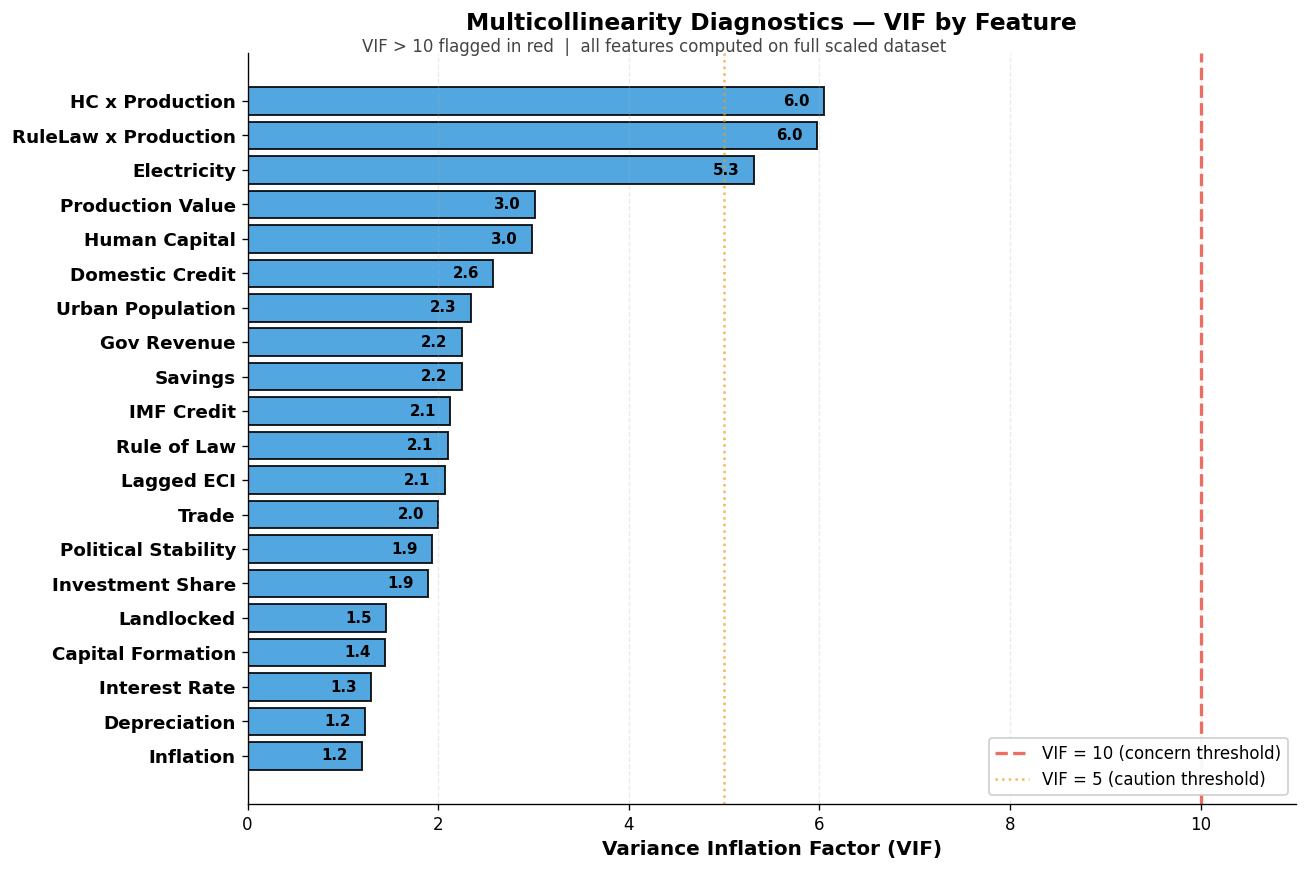

  ✓ Saved Graphics/NB5/VIF_model2_resource_rich.{png,pdf}

[2/4] Plotting 3-panel coefficient comparison...


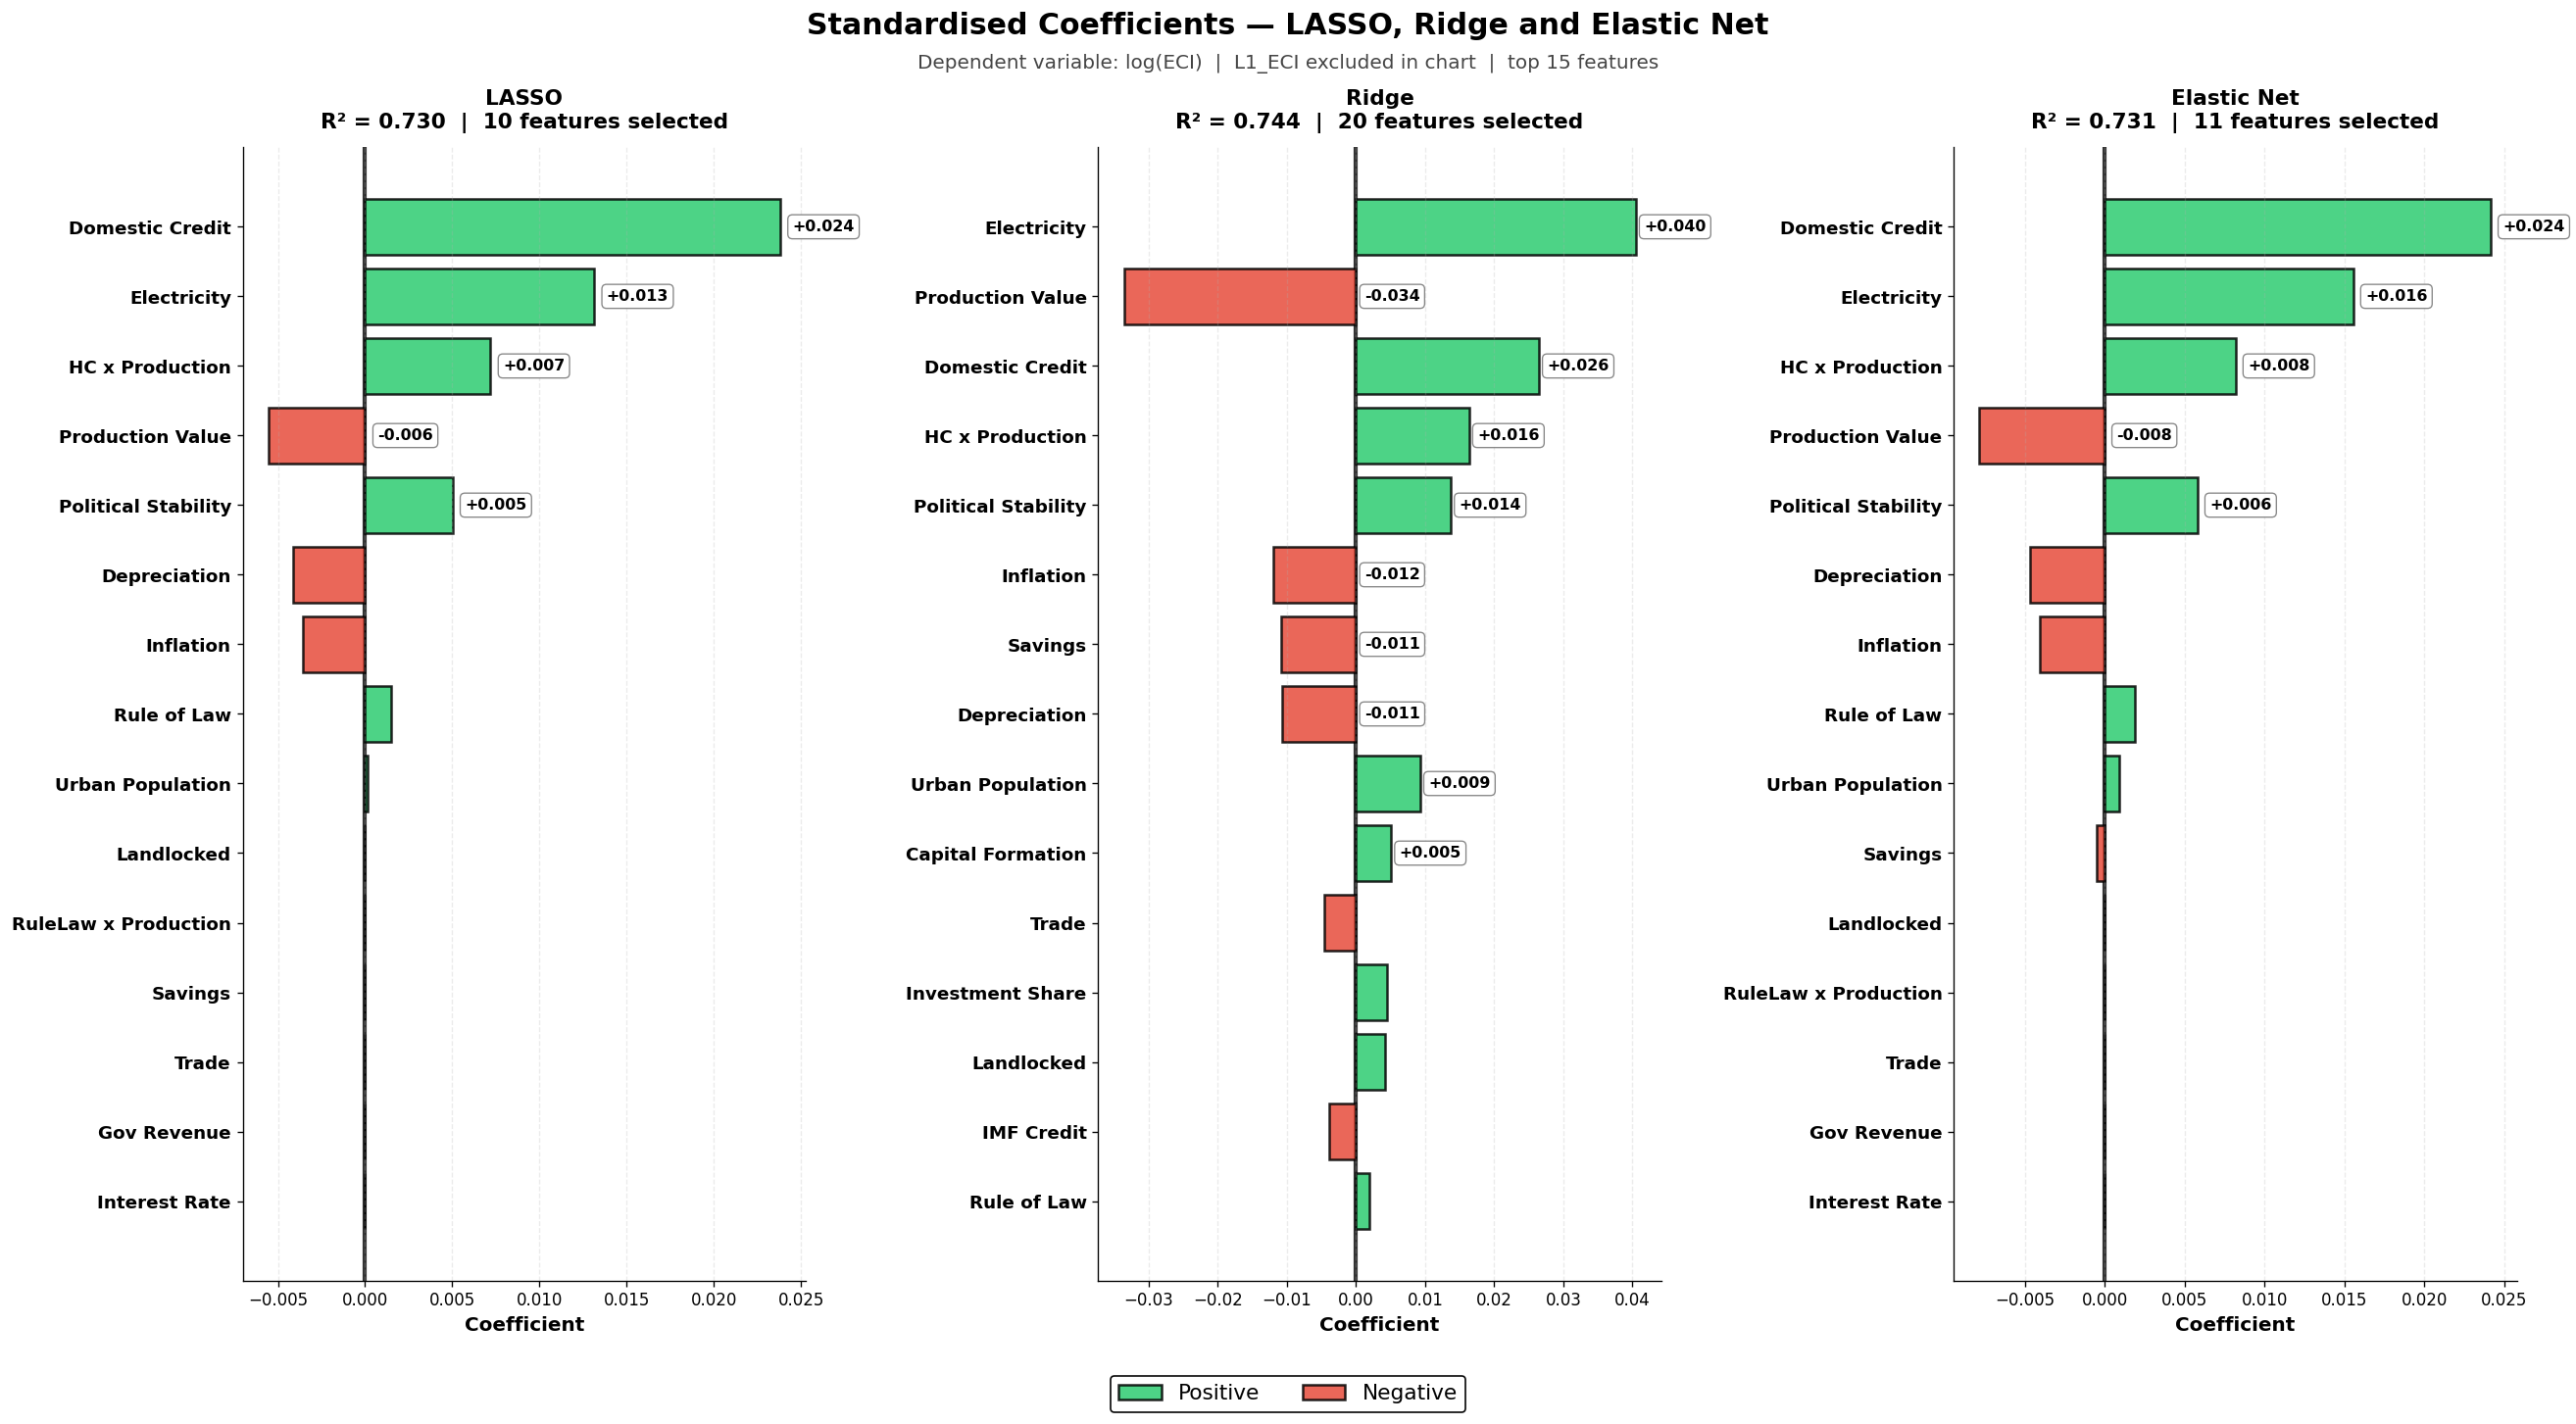

  ✓ Saved Coef_Comparison_model2_resource_rich.{png,pdf}

[3/4] Plotting model agreement chart...


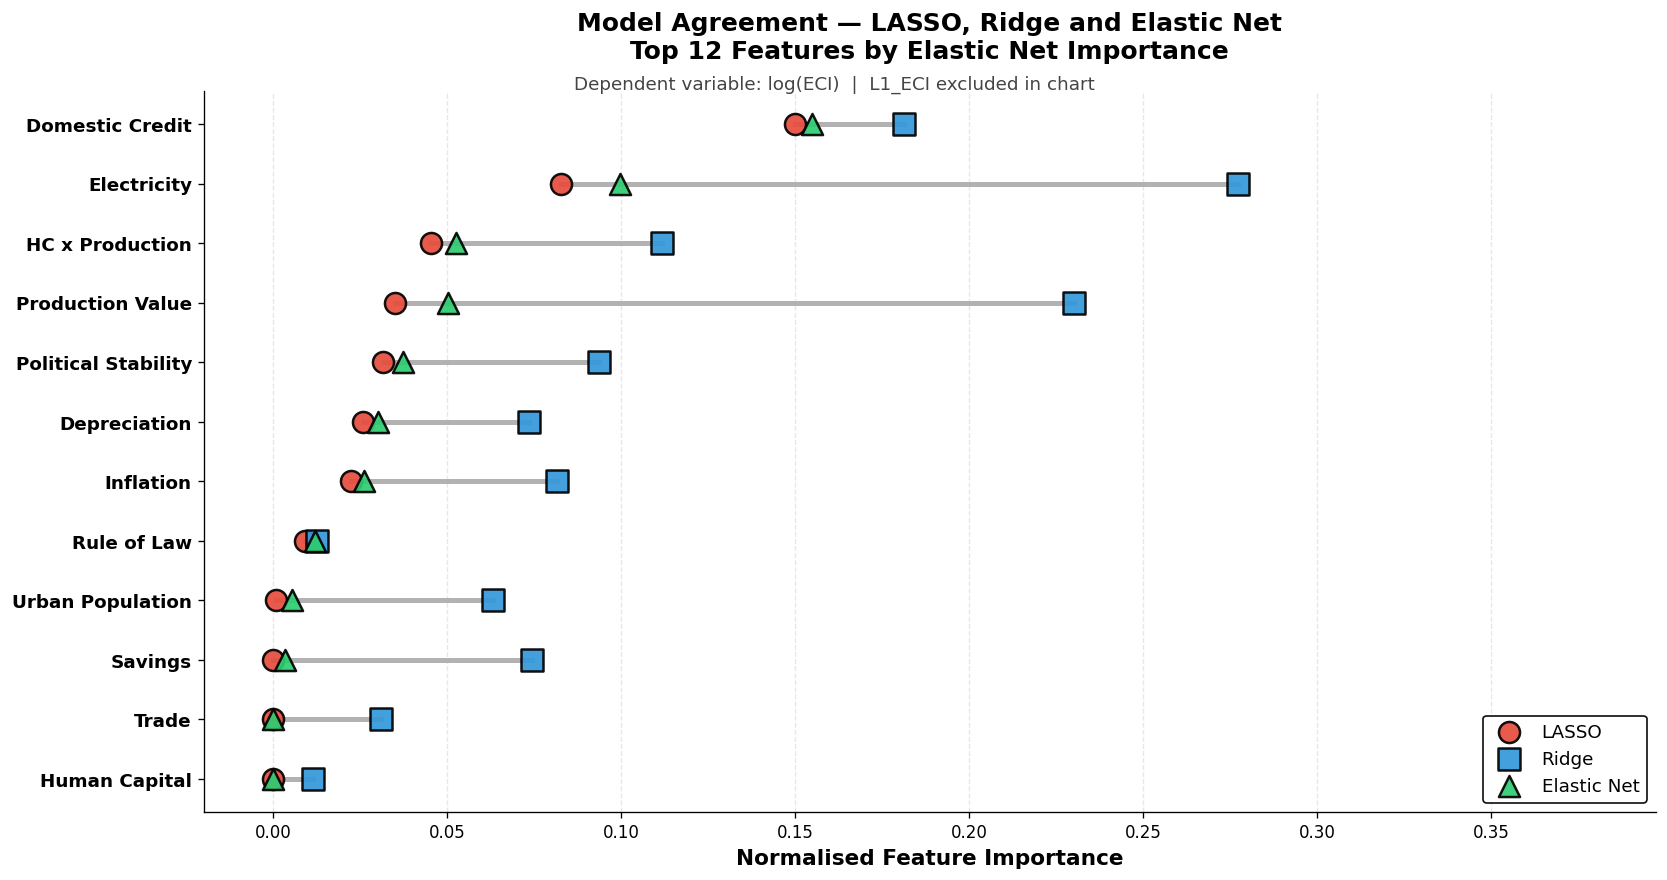

  ✓ Saved ModelAgreement_model2_resource_rich.{png,pdf}

[4/4] Plotting Random Forest importance...


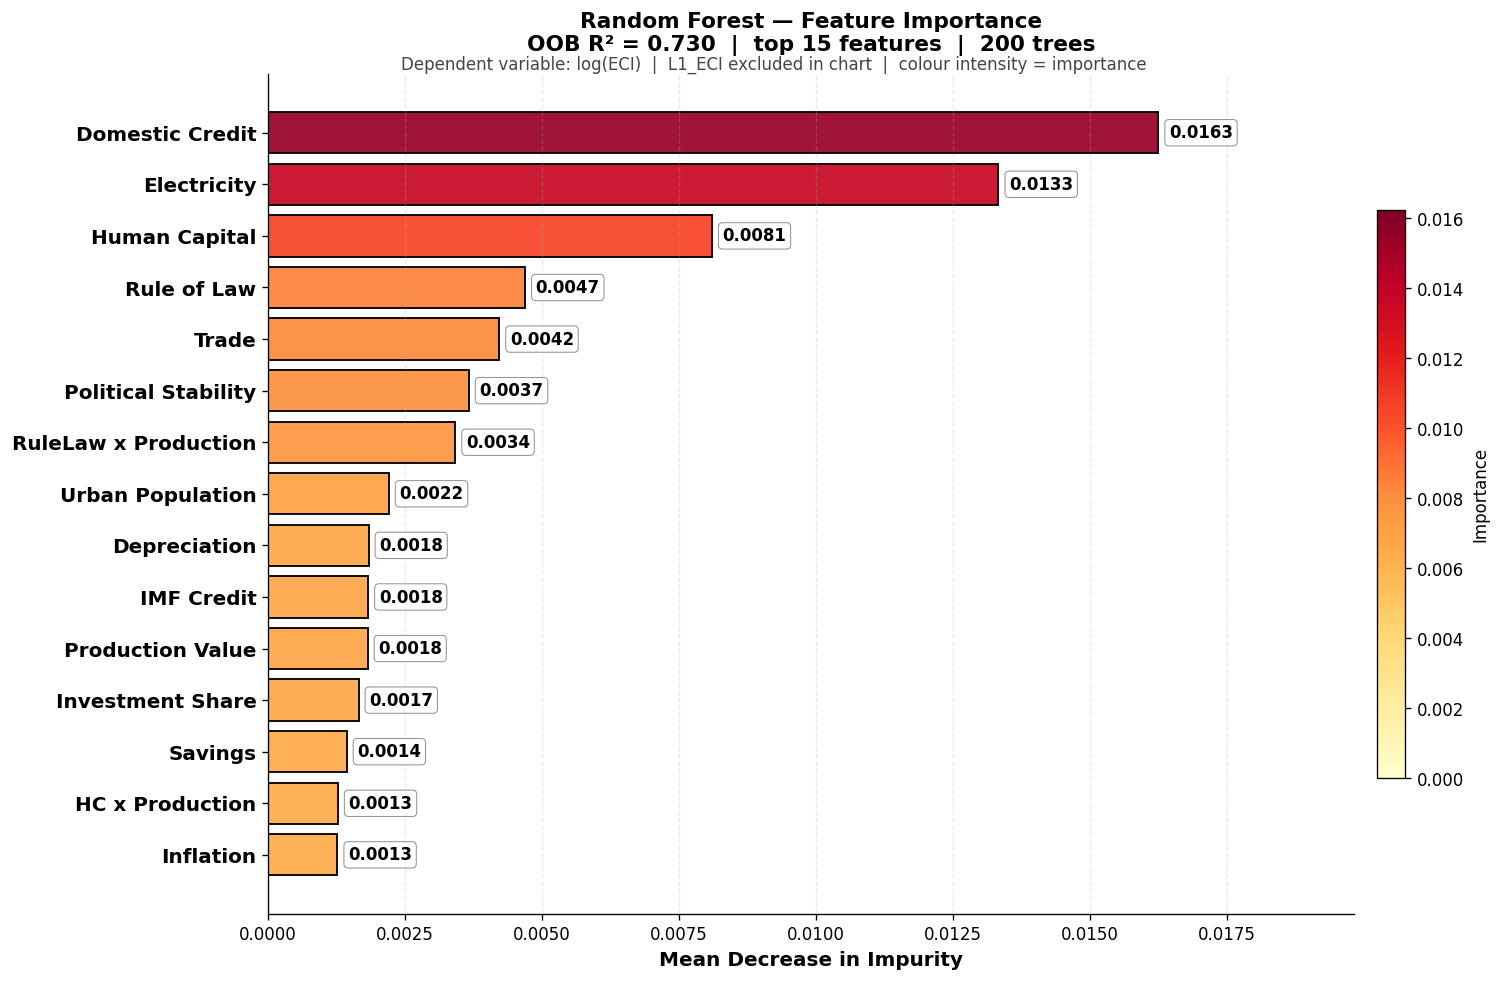

  ✓ Saved RF_model2_resource_rich.{png,pdf}

✓ All 4 static charts saved to Graphics\NB5/


In [6]:
plt.rcParams.update({
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'figure.dpi':       120,
})

# ── CHART 1: VIF ──────────────────────────────────────────────────────────────
print("[1/4] Plotting VIF chart...")

vif_plot = vif_data.copy()
vif_plot['Short'] = vif_plot['Feature'].apply(shorten_name)
vif_plot = vif_plot.sort_values('VIF', ascending=True).reset_index(drop=True)

bar_colors = ['#E74C3C' if v > 10 else '#3498DB' for v in vif_plot['VIF']]

fig, ax = plt.subplots(figsize=(11, 8))
y_pos = np.arange(len(vif_plot))

ax.barh(y_pos, vif_plot['VIF'], color=bar_colors, alpha=0.85,
        edgecolor='black', linewidth=1.2)
ax.axvline(10, color='#E74C3C', linewidth=2, linestyle='--', alpha=0.8,
           label='VIF = 10 (concern threshold)')
ax.axvline(5,  color='#F39C12', linewidth=1.5, linestyle=':',  alpha=0.7,
           label='VIF = 5 (caution threshold)')

ax.set_yticks(y_pos)
ax.set_yticklabels(vif_plot['Short'], fontsize=11, fontweight='bold')
ax.set_xlabel('Variance Inflation Factor (VIF)', fontsize=12, fontweight='bold')
ax.set_title('Multicollinearity Diagnostics — VIF by Feature',
             fontsize=14, fontweight='bold', pad=14)
plt.figtext(0.5, 0.86, 'VIF > 10 flagged in red  |  all features computed on full scaled dataset',
            ha='center', fontsize=10, color='#444')

for i, val in enumerate(vif_plot['VIF']):
    ax.text(min(val - 0.15, 10.8), i, f'{val:.1f}',
            va='center', ha='right', fontsize=9, fontweight='bold',
            color='black')

ax.set_xlim(0, 11)
ax.legend(fontsize=10, loc='lower right', framealpha=0.95)
ax.grid(axis='x', alpha=0.25, linestyle='--')
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(os.path.join(OUT, 'VIF_model2_resource_rich.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(OUT, 'VIF_model2_resource_rich.pdf'), bbox_inches='tight')
plt.show()
print(f"  ✓ Saved Graphics/NB5/VIF_model2_resource_rich.{{png,pdf}}")


# ── CHART 2: 3-Panel Coefficient Comparison (LASSO, Ridge, Elastic Net) ───────
print("\n[2/4] Plotting 3-panel coefficient comparison...")

fig, axes = plt.subplots(1, 3, figsize=(22, 12))

for idx, model_name in enumerate(['LASSO', 'Ridge', 'Elastic Net']):
    ax = axes[idx]

    signed_vals = models[model_name].coef_.copy()
    abs_vals    = np.abs(signed_vals)

    exclude_idx = all_features.index(EXCLUDE) if EXCLUDE in all_features else None
    if exclude_idx is not None:
        abs_vals[exclude_idx] = -np.inf

    top15_idx  = np.argsort(abs_vals)[::-1][:15]
    top15_feat = [all_features[i] for i in top15_idx]
    top15_vals = signed_vals[top15_idx]

    colors = ['#2ECC71' if v > 0 else '#E74C3C' for v in top15_vals]
    labels = [shorten_name(f) for f in top15_feat]
    y_pos  = np.arange(len(top15_feat))

    ax.barh(y_pos, top15_vals, color=colors, alpha=0.85,
            edgecolor='black', linewidth=1.5)
    ax.axvline(0, color='black', linewidth=2.5, alpha=0.8, zorder=0)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=11, fontweight='bold')
    ax.set_xlabel('Coefficient', fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.25, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    r2        = perf_df[perf_df['Model'] == model_name]['R²'].values[0]
    n_nonzero = int(np.sum(models[model_name].coef_ != 0))
    ax.set_title(f'{model_name}\nR² = {r2:.3f}  |  {n_nonzero} features selected',
                 fontsize=13, fontweight='bold', pad=12)

    x_max = max(abs(top15_vals)) if len(top15_vals) else 1
    for i, val in enumerate(top15_vals):
        if abs(val) > 0.005:
            x_pos = abs(val) + x_max * 0.03 if val > 0 else x_max * 0.03
            ax.text(x_pos, i, f'{val:+.3f}',
                    va='center', ha='left', fontsize=9.5, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                              alpha=0.95, edgecolor='gray', linewidth=0.8))

fig.legend(
    handles=[
        Patch(facecolor='#2ECC71', label='Positive', alpha=0.85, edgecolor='black', linewidth=1.5),
        Patch(facecolor='#E74C3C', label='Negative', alpha=0.85, edgecolor='black', linewidth=1.5),
    ],
    loc='lower center', bbox_to_anchor=(0.5, -0.02),
    ncol=2, fontsize=13, framealpha=0.98, edgecolor='black', fancybox=True
)

plt.suptitle('Standardised Coefficients — LASSO, Ridge and Elastic Net',
             fontsize=18, fontweight='bold', y=0.98)
plt.figtext(0.5, 0.94,
            'Dependent variable: log(ECI)  |  L1_ECI excluded in chart  |  top 15 features',
            ha='center', fontsize=12, color='#444')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig(os.path.join(OUT, 'Coef_Comparison_model2_resource_rich.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(OUT, 'Coef_Comparison_model2_resource_rich.pdf'), bbox_inches='tight')
plt.show()
print("  ✓ Saved Coef_Comparison_model2_resource_rich.{png,pdf}")


# ── CHART 3: Model Agreement — Dot-and-Range Plot ─────────────────────────────
print("\n[3/4] Plotting model agreement chart...")

imp_df = all_importance[all_importance['Feature'] != EXCLUDE].copy()
imp_df['EN_abs'] = imp_df['Elastic Net']
top12  = imp_df.sort_values('EN_abs', ascending=False).head(12).reset_index(drop=True)
top12['Short'] = top12['Feature'].apply(shorten_name)

fig, ax = plt.subplots(figsize=(14, 8))
y_pos = np.arange(len(top12))

for i, row in top12.iterrows():
    vals = [row['LASSO'], row['Ridge'], row['Elastic Net']]
    ax.plot([min(vals), max(vals)], [i, i],
            color='#555555', alpha=0.45, linewidth=3, zorder=1)
    ax.scatter(row['LASSO'],       i, marker='o', s=160, alpha=0.92,
               color='#E74C3C', edgecolor='black', linewidth=1.5, zorder=3,
               label='LASSO'       if i == 0 else '')
    ax.scatter(row['Ridge'],       i, marker='s', s=160, alpha=0.92,
               color='#3498DB', edgecolor='black', linewidth=1.5, zorder=3,
               label='Ridge'       if i == 0 else '')
    ax.scatter(row['Elastic Net'], i, marker='^', s=160, alpha=0.92,
               color='#2ECC71', edgecolor='black', linewidth=1.5, zorder=3,
               label='Elastic Net' if i == 0 else '')

ax.set_yticks(y_pos)
ax.set_yticklabels(top12['Short'], fontsize=11, fontweight='bold')
ax.set_xlabel('Normalised Feature Importance', fontsize=13, fontweight='bold')
ax.set_title('Model Agreement — LASSO, Ridge and Elastic Net\nTop 12 Features by Elastic Net Importance',
             fontsize=15, fontweight='bold', pad=20)
plt.figtext(0.5, 0.83,
            'Dependent variable: log(ECI)  |  L1_ECI excluded in chart',
            ha='center', fontsize=11, color='#444')
ax.invert_yaxis()
ax.legend(fontsize=11, loc='lower right', framealpha=0.95, edgecolor='black', ncol=1)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

x_max_val = max(top12[['LASSO', 'Ridge', 'Elastic Net']].max())
ax.set_xlim(-0.02, x_max_val + 0.12)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(os.path.join(OUT, 'ModelAgreement_model2_resource_rich.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(OUT, 'ModelAgreement_model2_resource_rich.pdf'), bbox_inches='tight')
plt.show()
print("  ✓ Saved ModelAgreement_model2_resource_rich.{png,pdf}")


# ── CHART 4: Random Forest feature importance ──────────────────────────────────
print("\n[4/4] Plotting Random Forest importance...")

rf_imp = pd.DataFrame({'Feature': all_features, 'Importance': rf.feature_importances_})
rf_top = (
    rf_imp[rf_imp['Feature'] != EXCLUDE]
    .sort_values('Importance', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

norm_vals  = rf_top['Importance'] / rf_top['Importance'].max()
cmap       = plt.cm.YlOrRd
bar_colors = [cmap(0.35 + 0.60 * v) for v in norm_vals]
y_pos      = np.arange(len(rf_top))

fig, ax = plt.subplots(figsize=(13, 9))
ax.barh(y_pos, rf_top['Importance'], color=bar_colors,
        edgecolor='black', linewidth=1.2, alpha=0.92)
ax.set_yticks(y_pos)
ax.set_yticklabels([shorten_name(f) for f in rf_top['Feature']],
                   fontsize=12, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.25, linestyle='--')
ax.set_xlim(right=rf_top['Importance'].max() * 1.22)

x_max_rf = rf_top['Importance'].max()
for i, val in enumerate(rf_top['Importance']):
    ax.text(val + x_max_rf * 0.012, i, f'{val:.4f}',
            va='center', ha='left', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      alpha=0.88, edgecolor='gray', linewidth=0.6))

ax.set_title(
    f'Random Forest — Feature Importance\n'
    f'OOB R² = {rf.oob_score_:.3f}  |  top 15 features  |  200 trees',
    fontsize=13, fontweight='bold', pad=14
)
plt.figtext(0.5, 0.85,
            'Dependent variable: log(ECI)  |  L1_ECI excluded in chart  |  colour intensity = importance',
            ha='center', fontsize=10, color='#444')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=x_max_rf))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.025, pad=0.02)
cbar.set_label('Importance', fontsize=10)

plt.tight_layout(rect=[0, 0, 0.97, 0.92])
plt.savefig(os.path.join(OUT, 'RF_model2_resource_rich.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(OUT, 'RF_model2_resource_rich.pdf'), bbox_inches='tight')
plt.show()
print("  ✓ Saved RF_model2_resource_rich.{png,pdf}")

print(f"\n✓ All 4 static charts saved to {OUT}/")

## 5b. Diagnostics — Summary Table

Heatmap-style table combining signed coefficients, normalised importance, VIF, and variable selection indicators across all linear models. Green = positive coefficient, red = negative, blue intensity = normalised importance, orange VIF = multicollinearity concern.

── Building summary table...

── Coefficient Summary Table ───────────────────────────────────────────
Feature                     LASSO    Ridge    E-Net   L-Imp   R-Imp  EN-Imp    VIF  L-Sel EN-Sel
───────────────────────────────────────────────────────────────────────────────────────────────
Domestic Credit            +0.024   +0.026   +0.024   0.150   0.181   0.155   2.58      ✓      ✓
Electricity                +0.013   +0.040   +0.016   0.083   0.277   0.100   5.31      ✓      ✓
HC x Production            +0.007   +0.016   +0.008   0.045   0.112   0.053   6.05      ✓      ✓
Production Value           -0.006   -0.034   -0.008   0.035   0.230   0.050   3.01      ✓      ✓
Political Stability        +0.005   +0.014   +0.006   0.032   0.094   0.037   1.94      ✓      ✓
Depreciation               -0.004   -0.011   -0.005   0.026   0.073   0.030   1.23      ✓      ✓
Inflation                  -0.004   -0.012   -0.004   0.023   0.081   0.026   1.20      ✓      ✓
Rule of Law              

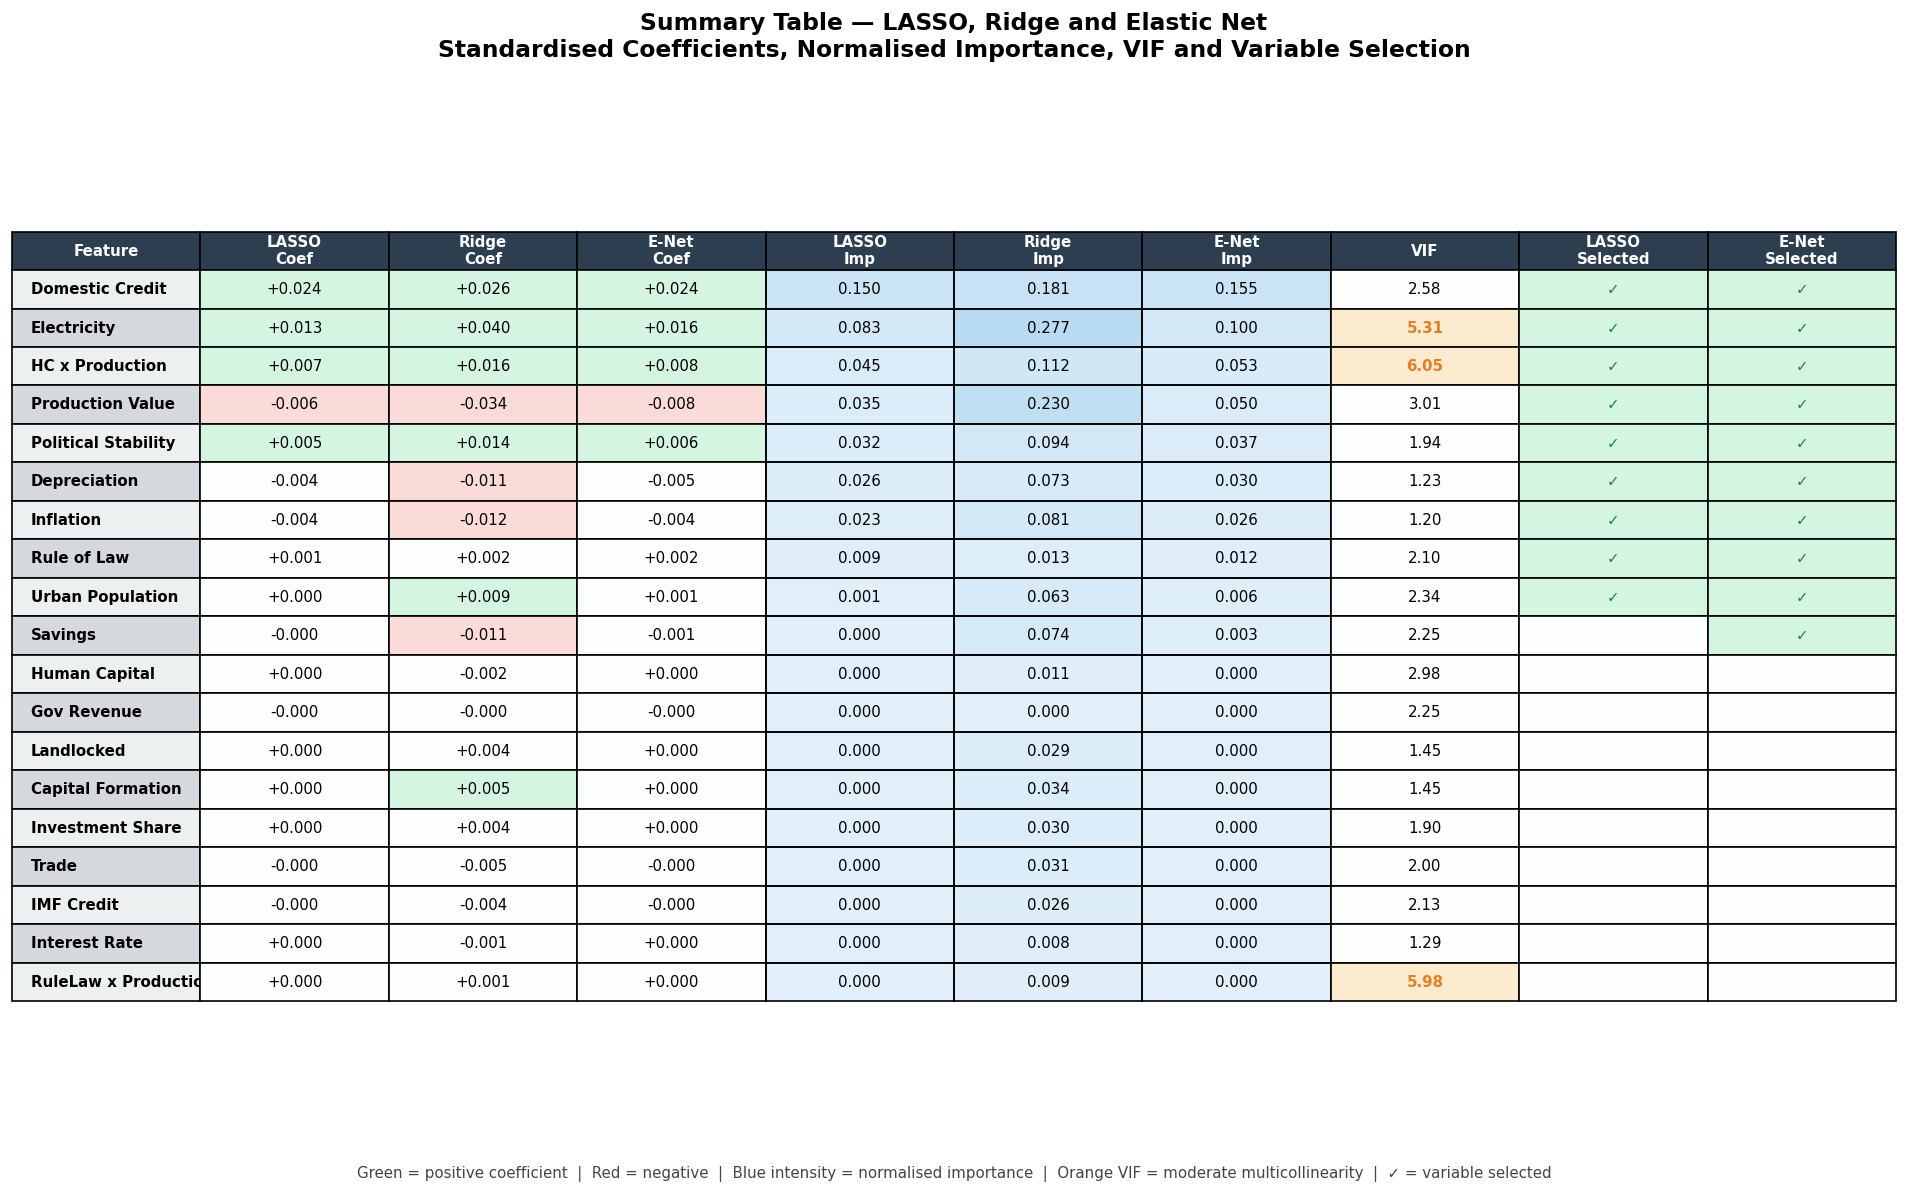

  ✓ Saved SummaryTable_model2_resource_rich.{png,pdf}


In [7]:
# ── Build summary table ───────────────────────────────────────────────────────
print("── Building summary table...")

table = pd.DataFrame({'Feature': all_features})
for name, model in lin_models.items():
    table[name] = model.coef_

for name in ['LASSO', 'Ridge', 'Elastic Net']:
    table[f'{name}_Imp'] = all_importance.set_index('Feature')[name].reindex(all_features).values

table = table.merge(vif_data, on='Feature')

table['LASSO_Selected']       = (table['LASSO']       != 0).astype(int)
table['Elastic Net_Selected'] = (table['Elastic Net'] != 0).astype(int)

table = (
    table[table['Feature'] != EXCLUDE]
    .assign(sort_key=lambda d: d['Elastic Net'].abs())
    .sort_values('sort_key', ascending=False)
    .drop(columns='sort_key')
    .reset_index(drop=True)
)
table['Feature'] = table['Feature'].apply(shorten_name)

# ── Console print ─────────────────────────────────────────────────────────────
print("\n── Coefficient Summary Table ───────────────────────────────────────────")
print(f"{'Feature':<24} {'LASSO':>8} {'Ridge':>8} {'E-Net':>8} "
      f"{'L-Imp':>7} {'R-Imp':>7} {'EN-Imp':>7} {'VIF':>6} {'L-Sel':>6} {'EN-Sel':>6}")
print("─" * 95)
for _, row in table.iterrows():
    print(f"{row['Feature']:<24} "
          f"{row['LASSO']:>+8.3f} "
          f"{row['Ridge']:>+8.3f} "
          f"{row['Elastic Net']:>+8.3f} "
          f"{row['LASSO_Imp']:>7.3f} "
          f"{row['Ridge_Imp']:>7.3f} "
          f"{row['Elastic Net_Imp']:>7.3f} "
          f"{row['VIF']:>6.2f} "
          f"{'✓' if row['LASSO_Selected'] else '':>6} "
          f"{'✓' if row['Elastic Net_Selected'] else '':>6}")

table.to_csv(os.path.join(OUT, 'coefficient_summary_table.csv'), index=False)
print("\n✓ Saved: Graphics/NB5/coefficient_summary_table.csv")

# ── Heatmap-style chart ───────────────────────────────────────────────────────
print("\n── Plotting summary table chart...")

fig, ax = plt.subplots(figsize=(16, 10))
ax.axis('off')

col_labels = [
    'Feature',
    'LASSO\nCoef', 'Ridge\nCoef', 'E-Net\nCoef',
    'LASSO\nImp', 'Ridge\nImp', 'E-Net\nImp',
    'VIF',
    'LASSO\nSelected', 'E-Net\nSelected'
]

cell_vals = []
for _, row in table.iterrows():
    cell_vals.append([
        row['Feature'],
        f"{row['LASSO']:+.3f}",
        f"{row['Ridge']:+.3f}",
        f"{row['Elastic Net']:+.3f}",
        f"{row['LASSO_Imp']:.3f}",
        f"{row['Ridge_Imp']:.3f}",
        f"{row['Elastic Net_Imp']:.3f}",
        f"{row['VIF']:.2f}",
        '✓' if row['LASSO_Selected']       else '',
        '✓' if row['Elastic Net_Selected'] else '',
    ])

tbl = ax.table(
    cellText=cell_vals,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.0, 1.6)

coef_cols = {1: 'LASSO', 2: 'Ridge', 3: 'Elastic Net'}
sel_cols  = {8: 'LASSO_Selected', 9: 'Elastic Net_Selected'}
vif_col   = 7

for row_idx, (_, row) in enumerate(table.iterrows(), start=1):
    for col_idx in range(len(col_labels)):
        cell = tbl[0, col_idx]
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold', fontsize=9)

    tbl[row_idx, 0].set_facecolor('#ECF0F1')
    tbl[row_idx, 0].set_text_props(fontweight='bold', ha='left')

    for col_idx, col_name in coef_cols.items():
        val = row[col_name]
        if val > 0.005:
            color = '#D5F5E3'
        elif val < -0.005:
            color = '#FADBD8'
        else:
            color = '#FDFEFE'
        tbl[row_idx, col_idx].set_facecolor(color)

    for col_idx, imp_col in [(4, 'LASSO_Imp'), (5, 'Ridge_Imp'), (6, 'Elastic Net_Imp')]:
        val   = row[imp_col]
        alpha = 0.15 + 0.70 * val
        color = mcolors.to_rgba('#3498DB', alpha=alpha)
        tbl[row_idx, col_idx].set_facecolor(color)

    vif_val = row['VIF']
    if vif_val > 10:
        tbl[row_idx, vif_col].set_facecolor('#FADBD8')
        tbl[row_idx, vif_col].set_text_props(color='#C0392B', fontweight='bold')
    elif vif_val > 5:
        tbl[row_idx, vif_col].set_facecolor('#FDEBD0')
        tbl[row_idx, vif_col].set_text_props(color='#E67E22', fontweight='bold')
    else:
        tbl[row_idx, vif_col].set_facecolor('#FDFEFE')

    for col_idx, sel_col in sel_cols.items():
        if row[sel_col]:
            tbl[row_idx, col_idx].set_facecolor('#D5F5E3')
            tbl[row_idx, col_idx].set_text_props(color='#1E8449', fontweight='bold')
        else:
            tbl[row_idx, col_idx].set_facecolor('#FDFEFE')

    if row_idx % 2 == 0:
        tbl[row_idx, 0].set_facecolor('#D5D8DC')

ax.set_title(
    'Summary Table — LASSO, Ridge and Elastic Net\n'
    'Standardised Coefficients, Normalised Importance, VIF and Variable Selection',
    fontsize=14, fontweight='bold', pad=16, y=0.98
)
plt.figtext(
    0.5, 0.01,
    'Green = positive coefficient  |  Red = negative  |  Blue intensity = normalised importance  '
    '|  Orange VIF = moderate multicollinearity  |  ✓ = variable selected',
    ha='center', fontsize=9, color='#444'
)

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'SummaryTable_model2_resource_rich.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(OUT, 'SummaryTable_model2_resource_rich.pdf'), bbox_inches='tight')
plt.show()
print("  ✓ Saved SummaryTable_model2_resource_rich.{png,pdf}")

## 6. Visualisations — Interactive (Plotly)

Four interactive HTML charts matching the portfolio style (`#fafafa` background, IBM Plex Sans font, `#1a2744` title colour). Saved as `.html` (always) and `.png` via kaleido if available. Same content as the static charts but hover-enabled for drill-down.

In [14]:
# ── Plotly style system ───────────────────────────────────────────────────────
STYLE = {
    'font_family': 'IBM Plex Sans, -apple-system, BlinkMacSystemFont, sans-serif',
    'tick_size': 11,
    'axis_title_size': 13,
    'legend_size': 11,
    'annotation_size': 15,
    'title_color': '#1a2744',
    'template': 'plotly_white',
    'plot_bg': '#fafafa',
    'paper_bg': '#fafafa',
    'chart_height': 550,
    'chart_height_small': 420,
    'chart_height_tall': 700,
    'margin': dict(l=60, r=40, t=10, b=50),
    'margin_bar': dict(l=160, r=130, t=10, b=50),
    'grid_color': '#e5e7eb',
    'grid_width': 0.5,
    'zero_line_color': '#c9cfd6',
}
WRITE_CONFIG = {'displayModeBar': False, 'responsive': True}

PALETTE = {
    'blue':        '#4a6fa5',
    'red':         '#c23a3a',
    'green':       '#2e7d4a',
    'orange':      '#d4853b',
    'light_blue':  '#7a9dc4',
    'light_red':   '#d46b6b',
    'light_green': '#5aa87a',
    'dark':        '#3d4f5f',
    'grey':        '#999999',
    'gold':        '#e6b980',
}

def base_layout(**kwargs):
    layout = dict(
        template=STYLE['template'],
        plot_bgcolor=STYLE['plot_bg'],
        paper_bgcolor=STYLE['paper_bg'],
        font=dict(family=STYLE['font_family'], size=STYLE['tick_size'],
                  color=STYLE['title_color']),
        margin=STYLE['margin'],
        height=STYLE['chart_height'],
    )
    layout.update(kwargs)
    return layout

def save_chart(fig, path_no_ext, width=1100, height=700):
    """Display inline, save .html and attempt .png."""
    fig.show()
    fig.write_html(f"{path_no_ext}.html", config=WRITE_CONFIG)
    print(f"  ✓ {path_no_ext}.html")
    for engine in ['kaleido', 'orca']:
        try:
            fig.write_image(f"{path_no_ext}.png", width=width, height=height,
                            scale=3, engine=engine)
            print(f"  ✓ {path_no_ext}.png ({engine})")
            return
        except Exception:
            pass
    print("  ⚠ PNG export skipped (kaleido not available). HTML saved.")


# ══════════════════════════════════════════════════════════════════════════════
# CHART 1: VIF (interactive)
# ══════════════════════════════════════════════════════════════════════════════
print("[1/4] VIF chart...")

vif_plot = vif_data.copy()
vif_plot['Short'] = vif_plot['Feature'].apply(shorten_name)
vif_plot = vif_plot.sort_values('VIF', ascending=True).reset_index(drop=True)

colors_vif = [PALETTE['red'] if v > 10 else PALETTE['blue'] for v in vif_plot['VIF']]

fig1 = go.Figure()
fig1.add_trace(go.Bar(
    y=vif_plot['Short'],
    x=vif_plot['VIF'],
    orientation='h',
    marker=dict(color=colors_vif, line=dict(color='#1a2744', width=0.5)),
    text=[f'{v:.1f}' for v in vif_plot['VIF']],
    textposition='outside',
    textfont=dict(size=STYLE['annotation_size'], color=STYLE['title_color']),
))
fig1.add_vline(x=10, line=dict(color=PALETTE['red'], width=2, dash='dash'),
               annotation_text='VIF = 10', annotation_position='right',
               annotation_font=dict(size=STYLE['annotation_size'], color=PALETTE['red']))
fig1.add_vline(x=5, line=dict(color=PALETTE['orange'], width=1.5, dash='dot'),
               annotation_text='VIF = 5', annotation_position='right',
               annotation_font=dict(size=STYLE['annotation_size'], color=PALETTE['orange']))
fig1.update_layout(**base_layout(
    height=STYLE['chart_height_tall'],
    margin=STYLE['margin_bar'],
    xaxis=dict(
        title=dict(text='Variance Inflation Factor (VIF)', font=dict(size=STYLE['axis_title_size'])),
        gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width'],
        range=[0, max(vif_plot['VIF'].max() * 1.15, 12)],
    ),
    yaxis=dict(tickfont=dict(size=STYLE['tick_size'])),
    showlegend=False,
))
save_chart(fig1, os.path.join(OUT, 'VIF_model2_resource_rich_interactive'), width=1100, height=700)


# ══════════════════════════════════════════════════════════════════════════════
# CHART 2: 3-Panel Coefficient Comparison (interactive)
# ══════════════════════════════════════════════════════════════════════════════
print("\n[2/4] 3-panel coefficient comparison...")

model_names_lin = ['LASSO', 'Ridge', 'Elastic Net']

fig2 = make_subplots(
    rows=1, cols=3,
    subplot_titles=[
        f"<b>{n}</b><br><span style='font-size:11px;color:#666'>R² = {perf_df[perf_df['Model']==n]['R²'].values[0]:.3f} | "
        f"{int(np.sum(models[n].coef_ != 0))} features</span>"
        for n in model_names_lin
    ],
    horizontal_spacing=0.08,
)

for col_idx, model_name in enumerate(model_names_lin, 1):
    signed_vals = models[model_name].coef_.copy()
    abs_vals    = np.abs(signed_vals)

    exclude_idx = all_features.index(EXCLUDE) if EXCLUDE in all_features else None
    if exclude_idx is not None:
        abs_vals[exclude_idx] = -np.inf

    top15_idx  = np.argsort(abs_vals)[::-1][:15]
    top15_feat = [all_features[i] for i in top15_idx]
    top15_vals = signed_vals[top15_idx]

    colors = [PALETTE['green'] if v > 0 else PALETTE['red'] for v in top15_vals]
    labels = [shorten_name(f) for f in top15_feat]

    labels_r = labels[::-1]
    vals_r   = top15_vals[::-1]
    colors_r = colors[::-1]

    fig2.add_trace(go.Bar(
        y=labels_r,
        x=vals_r,
        orientation='h',
        marker=dict(color=colors_r, line=dict(color='#1a2744', width=0.5)),
        text=[f'{v:+.3f}' if abs(v) > 0.005 else '' for v in vals_r],
        textposition='outside',
        textfont=dict(size=9, color=STYLE['title_color']),
        showlegend=False,
    ), row=1, col=col_idx)

    fig2.add_vline(x=0, line=dict(color=STYLE['zero_line_color'], width=2),
                   row=1, col=col_idx)
    x_pad = max(abs(vals_r.min()), abs(vals_r.max())) * 0.35
    fig2.update_xaxes(
        title_text='Coefficient' if col_idx == 2 else '',
        title_font=dict(size=STYLE['axis_title_size']),
        gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width'],
        range=[vals_r.min() - x_pad, vals_r.max() + x_pad],
        row=1, col=col_idx,
    )
    fig2.update_yaxes(tickfont=dict(size=STYLE['tick_size']), row=1, col=col_idx)

fig2.add_trace(go.Bar(y=[None], x=[None], marker_color=PALETTE['green'],
                       name='Positive', showlegend=True))
fig2.add_trace(go.Bar(y=[None], x=[None], marker_color=PALETTE['red'],
                       name='Negative', showlegend=True))
fig2.update_layout(**base_layout(
    height=STYLE['chart_height_tall'],
    width=1600,
    margin=dict(l=160, r=80, t=70, b=100),
    legend=dict(
        orientation='h', yanchor='top', y=-0.15, xanchor='center', x=0.5,
        font=dict(size=STYLE['legend_size']),
    ),
))
save_chart(fig2, os.path.join(OUT, 'Coef_Comparison_model2_resource_rich_interactive'), width=1600, height=700)


# ══════════════════════════════════════════════════════════════════════════════
# CHART 3: Model Agreement (interactive)
# ══════════════════════════════════════════════════════════════════════════════
print("\n[3/4] Model agreement chart...")

imp_df = all_importance[all_importance['Feature'] != EXCLUDE].copy()
imp_df['EN_abs'] = imp_df['Elastic Net']
top12  = imp_df.sort_values('EN_abs', ascending=False).head(12).reset_index(drop=True)
top12['Short'] = top12['Feature'].apply(shorten_name)
top12_r = top12.iloc[::-1].reset_index(drop=True)

fig3 = go.Figure()

for _, row in top12_r.iterrows():
    vals = [row['LASSO'], row['Ridge'], row['Elastic Net']]
    fig3.add_trace(go.Scatter(
        x=[min(vals), max(vals)],
        y=[row['Short'], row['Short']],
        mode='lines',
        line=dict(color='#aab0b8', width=3),
        showlegend=False,
        hoverinfo='skip',
    ))

dot_config = [
    ('LASSO',       'circle',      PALETTE['red']),
    ('Ridge',       'square',      PALETTE['blue']),
    ('Elastic Net', 'triangle-up', PALETTE['green']),
]
for model_name, symbol, color in dot_config:
    fig3.add_trace(go.Scatter(
        x=top12_r[model_name],
        y=top12_r['Short'],
        mode='markers',
        marker=dict(symbol=symbol, size=12, color=color,
                    line=dict(color='#1a2744', width=1)),
        name=model_name,
        hovertemplate='%{y}: %{x:.3f}<extra>' + model_name + '</extra>',
    ))

fig3.update_layout(**base_layout(
    height=STYLE['chart_height'],
    margin=STYLE['margin_bar'],
    xaxis=dict(
        title=dict(text='Normalised Feature Importance',
                   font=dict(size=STYLE['axis_title_size'])),
        gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width'],
        range=[-0.02, top12[['LASSO', 'Ridge', 'Elastic Net']].max().max() + 0.08],
    ),
    yaxis=dict(tickfont=dict(size=STYLE['tick_size'])),
    legend=dict(
        font=dict(size=STYLE['legend_size']),
        yanchor='bottom', y=0.02, xanchor='right', x=0.98,
        bgcolor='rgba(250,250,250,0.95)', bordercolor='#e5e7eb', borderwidth=1,
    ),
))
save_chart(fig3, os.path.join(OUT, 'ModelAgreement_model2_resource_rich_interactive'), width=1100, height=600)


# ══════════════════════════════════════════════════════════════════════════════
# CHART 4: Random Forest Feature Importance (interactive)
# ══════════════════════════════════════════════════════════════════════════════
print("\n[4/4] Random Forest importance...")

rf_imp = pd.DataFrame({'Feature': all_features, 'Importance': rf.feature_importances_})
rf_top = (
    rf_imp[rf_imp['Feature'] != EXCLUDE]
    .sort_values('Importance', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

norm_vals = rf_top['Importance'] / rf_top['Importance'].max()
def lerp_color(t, c_low=(230, 185, 128), c_high=(180, 80, 40)):
    return f'rgb({int(c_low[0]+(c_high[0]-c_low[0])*t)},{int(c_low[1]+(c_high[1]-c_low[1])*t)},{int(c_low[2]+(c_high[2]-c_low[2])*t)})'

bar_colors_rf = [lerp_color(v) for v in norm_vals]
rf_top_r = rf_top.iloc[::-1].reset_index(drop=True)
bar_colors_rf_r = bar_colors_rf[::-1]

fig4 = go.Figure()
fig4.add_trace(go.Bar(
    y=[shorten_name(f) for f in rf_top_r['Feature']],
    x=rf_top_r['Importance'],
    orientation='h',
    marker=dict(color=bar_colors_rf_r, line=dict(color='#1a2744', width=0.5)),
    text=[f'{v:.4f}' for v in rf_top_r['Importance']],
    textposition='outside',
    textfont=dict(size=STYLE['annotation_size'], color=STYLE['title_color']),
))
fig4.update_layout(**base_layout(
    height=STYLE['chart_height_tall'],
    margin=STYLE['margin_bar'],
    xaxis=dict(
        title=dict(text='Mean Decrease in Impurity',
                   font=dict(size=STYLE['axis_title_size'])),
        gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width'],
        range=[0, rf_top['Importance'].max() * 1.22],
    ),
    yaxis=dict(tickfont=dict(size=STYLE['tick_size'])),
    showlegend=False,
    annotations=[dict(
        text=f"OOB R² = {rf.oob_score_:.3f}  |  200 trees  |  max_depth = 4",
        xref='paper', yref='paper', x=0.98, y=0.02,
        showarrow=False,
        font=dict(size=STYLE['annotation_size'], color='#666'),
        bgcolor='rgba(250,250,250,0.95)', bordercolor='#e5e7eb', borderwidth=1,
        borderpad=6,
    )],
))
save_chart(fig4, os.path.join(OUT, 'RF_model2_resource_rich_interactive'), width=1100, height=700)

print(f"\n✓ All 4 interactive charts saved to {OUT}/")

[1/4] VIF chart...


  ✓ Graphics\NB5\VIF_model2_resource_rich_interactive.html
  ✓ Graphics\NB5\VIF_model2_resource_rich_interactive.png (kaleido)

[2/4] 3-panel coefficient comparison...


  ✓ Graphics\NB5\Coef_Comparison_model2_resource_rich_interactive.html
  ✓ Graphics\NB5\Coef_Comparison_model2_resource_rich_interactive.png (kaleido)

[3/4] Model agreement chart...


  ✓ Graphics\NB5\ModelAgreement_model2_resource_rich_interactive.html
  ✓ Graphics\NB5\ModelAgreement_model2_resource_rich_interactive.png (kaleido)

[4/4] Random Forest importance...


  ✓ Graphics\NB5\RF_model2_resource_rich_interactive.html
  ✓ Graphics\NB5\RF_model2_resource_rich_interactive.png (kaleido)

✓ All 4 interactive charts saved to Graphics\NB5/


## Summary

| Item | Value |
|---|---|
| Sample | 54 resource-rich countries, 1995–2019 |
| Dependent variable | log(ECI), shift-adjusted |
| Features | 20 (18 base + 2 interactions) |
| Best model (in-sample R²) | Random Forest |
| Regularisation CV | TimeSeriesSplit(n_splits=5, gap=1) |
| Graphics output | `Graphics/NB5/` (PNG + PDF + HTML) |

In [9]:
# ── NB5 SUMMARY ──────────────────────────────────────────────────────────────
n_countries = df['Country Code'].nunique()
n_years     = df['Year'].nunique()
n_obs       = len(df)
n_features  = len(all_features)

lasso_selected = int(np.sum(lasso.coef_ != 0))
en_selected    = int(np.sum(elastic.coef_ != 0))

top5_features = (
    all_importance[all_importance['Feature'] != EXCLUDE]
    .head(5)['Feature']
    .apply(shorten_name)
    .tolist()
)

print("=" * 60)
print("  NB5 SUMMARY — Supervised ML: Drivers of ECI")
print("=" * 60)
print(f"  Sample       : {n_countries} countries × {n_years} years = {n_obs} obs")
print(f"  Features     : {n_features} ({', '.join([shorten_name(f) for f in all_features[:3]])} …)")
print()
print("  Model performance (in-sample):")
for _, row in perf_df.iterrows():
    print(f"    {row['Model']:<14}  R²={row['R²']:.4f}  RMSE={row['RMSE']:.4f}  MAE={row['MAE']:.4f}")
print()
print(f"  Best alpha (LASSO)      : {lasso.alpha_:.4f}")
print(f"  Best alpha (Ridge)      : {ridge.alpha_:.4f}")
print(f"  Best alpha (Elastic Net): {elastic.alpha_:.4f}  l1_ratio={elastic.l1_ratio_:.2f}")
print(f"  RF OOB R²               : {rf.oob_score_:.4f}")
print()
print(f"  LASSO selected {lasso_selected} / {n_features} features")
print(f"  Elastic Net selected {en_selected} / {n_features} features")
print(f"  Top 5 by Elastic Net importance: {top5_features}")
print()
print(f"  Graphics saved to: {OUT}/")
print("=" * 60)

  NB5 SUMMARY — Supervised ML: Drivers of ECI
  Sample       : 53 countries × 24 years = 1240 obs
  Features     : 20 (Production Value, Human Capital, Rule of Law …)

  Model performance (in-sample):
    Random Forest   R²=0.7846  RMSE=0.1044  MAE=0.0651
    Ridge           R²=0.7437  RMSE=0.1139  MAE=0.0747
    Elastic Net     R²=0.7313  RMSE=0.1166  MAE=0.0741
    LASSO           R²=0.7295  RMSE=0.1170  MAE=0.0741

  Best alpha (LASSO)      : 0.0066
  Best alpha (Ridge)      : 0.8111
  Best alpha (Elastic Net): 0.0124  l1_ratio=0.50
  RF OOB R²               : 0.7303

  LASSO selected 10 / 20 features
  Elastic Net selected 11 / 20 features
  Top 5 by Elastic Net importance: ['Domestic Credit', 'Electricity', 'Production Value', 'HC x Production', 'Political Stability']

  Graphics saved to: Graphics\NB5/
